In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
from pathlib import Path
from torchvision.datasets.utils import download_url
_old_sys_path = sys.path.copy()
try:
    project_root = Path.cwd().parent.parent
    sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
    from functions import graph_print_analysis as gp_tool
    from train_mnist_with_network import HBModel_MNIST as hbm

finally:
    sys.path = _old_sys_path



Project root added to sys.path: c:\Users\ASUS\Desktop\cone_dynamics


In [2]:
num_epochs = 2
lr = 1e-2
if_decay = True
batch_sizes = {16, 32, 64, 128, 256, 512, 1024}
batch_size=8192
steps = {200, 400, 800, 1200, 1600, 2000}
step=1000
lrs={1e-4,1e-3, 1e-2, 1e-1}
decays={0, 1e-3, 1e-1}
if_regularize=True

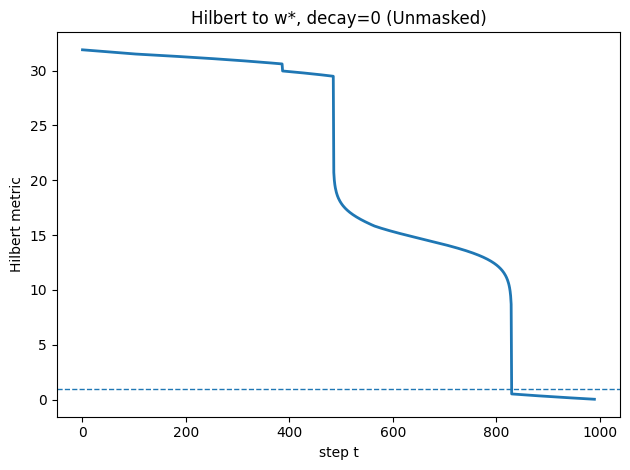

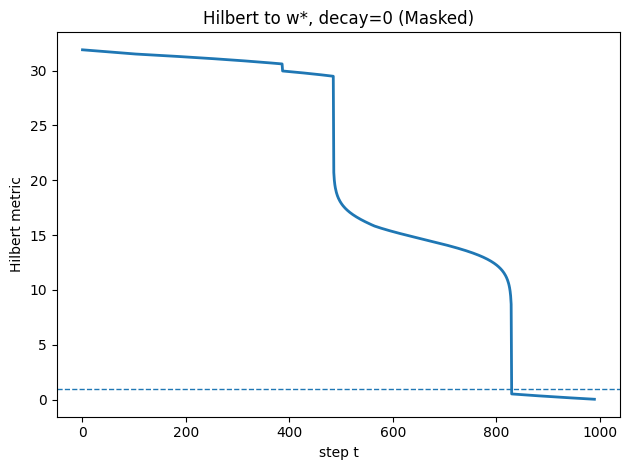

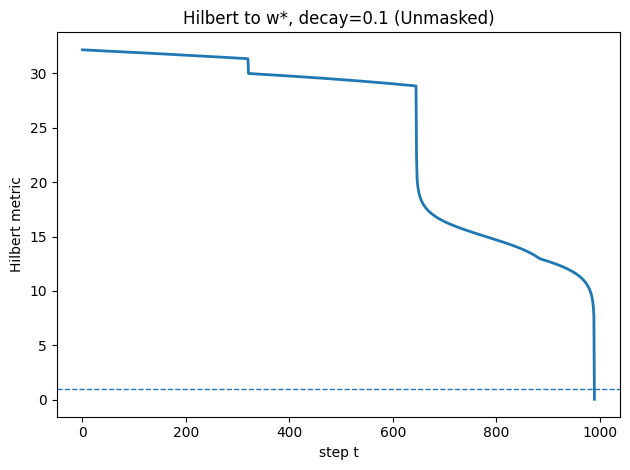

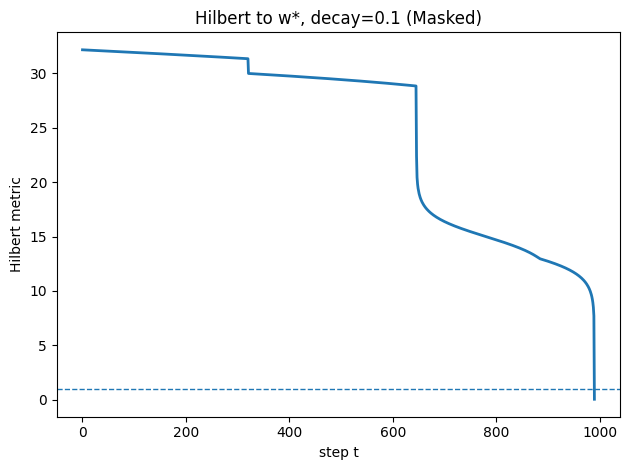

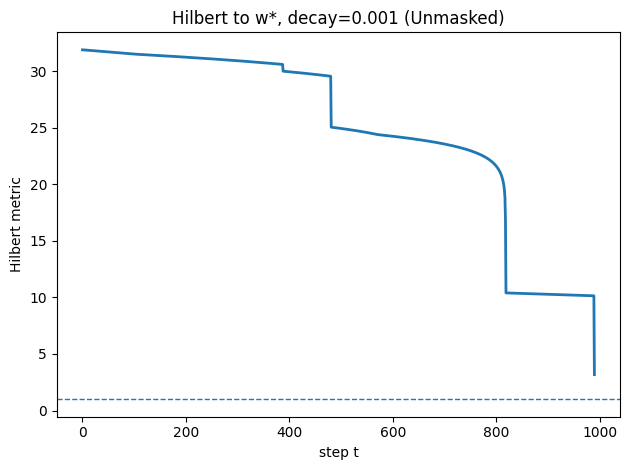

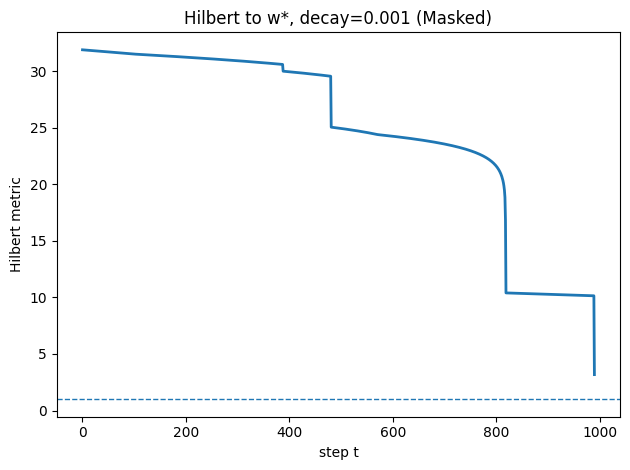

In [3]:
unmasks={}
for decay in decays:
    res=hbm.train_with_optional_initialization(num_steps=step,
        sample_size=batch_size,
        lr=lr,
        if_decay=if_decay,
        number_of_layerss=20,
        if_initialize=True,regularization_coeff=decay,seed=1919810)
    trajec=res['param_traj']
    w_star=trajec[-1]
    trajec=trajec[:-10]
    analysis_result=gp_tool.analysis_to_w_star(trajectory=trajec, w_star=w_star, if_show=True, if_print=False, if_writes=False, plt_title=f"Hilbert to w*, decay={decay}", if_masked=True,if_smooth=False)
    unmasks[decay]=analysis_result

In [ ]:
from matplotlib import pyplot as plt

3


In [10]:
print(unmasks[0].keys())

dict_keys(['hilbert_to_w_star', 'hilbert_to_w_star_masked'])


In [11]:
HTF_Unmasked={}
HTF_Masked={}
for decay in decays:
    HTF_Unmasked[decay]=unmasks[decay]['hilbert_to_w_star']
    HTF_Masked[decay]=unmasks[decay]['hilbert_to_w_star_masked']

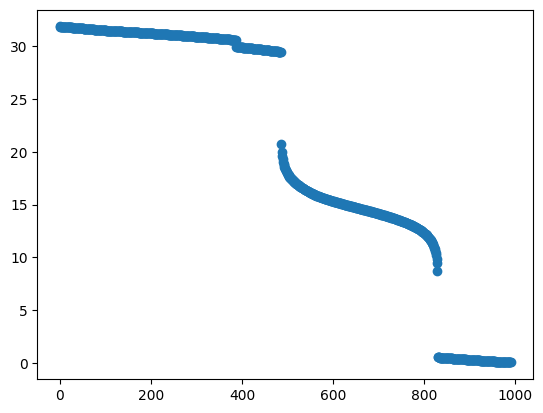

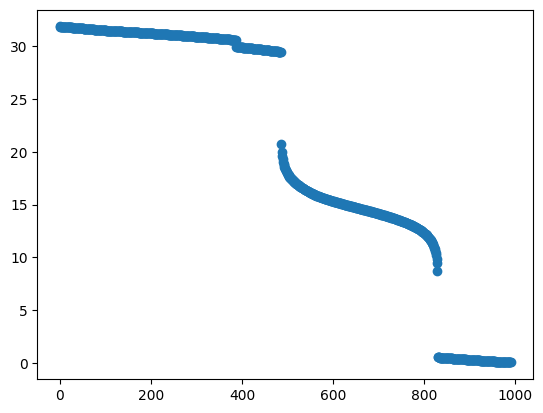

In [14]:
plt.scatter(range(len(HTF_Unmasked[0])),HTF_Unmasked[0],label='decay=0 unmasked')
plt.show()
plt.scatter(range(len(HTF_Masked[0])),HTF_Masked[0],label='decay=0 masked')
plt.show()

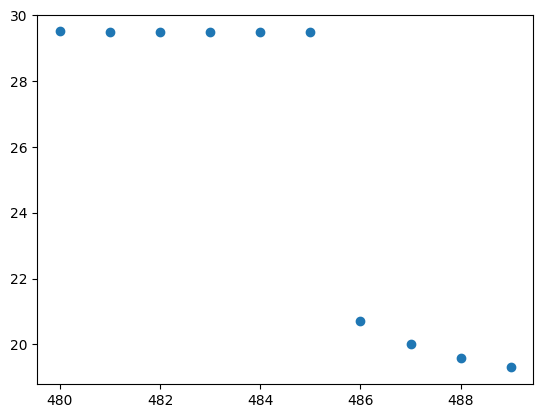

In [22]:
plt.scatter(range(480,490),HTF_Masked[0][480:490])


In [ ]:
def hilbert_distance(x, y, eps=1e-10):
    """
    x, y: (m,) positive (>0)
    d_H(x, y) = log( max_i x_i / y_i ) - log( min_i x_i / y_i )

    Return a Python float
    """
    if not torch.is_tensor(x):
        x = torch.as_tensor(x)
    if not torch.is_tensor(y):
        y = torch.as_tensor(y)

    x = x.view(-1)
    y = y.view(-1)

    if (x < eps).any() or (y < eps).any():
        raise ValueError("Inputs to hilbert_distance must be strictly positive.")

    ratio = x / y
    max_r = ratio.max()
    min_r = ratio.min()
    return {
        'hilbert_distance': torch.log(max_r) - torch.log(min_r),
        'max_ratio': max_r,
        'min_ratio': min_r
    }

In [ ]:
special_traj=param_traj[480:490]
for 